<a href="https://colab.research.google.com/github/greeshmakrishnan00/Machine-Learning/blob/main/Real_Estate_Regression_ML_(Random_Forest).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Random Forest**

# Regression

# Load and Inspect data set

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/oregon_real_estate_2026_ultimate.csv")
df.head()

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
0,single_family,NaN,Showings subject to accepted offer. Investor o...,179950.0,698.0,1.0,2.0,1.0,1.0,1.0,NaN,1897.0
1,single_family,NaN,*DO NOT DRIVE BY WITHOUT AN APPOINTMENT* Distr...,399900.0,2736.0,2.0,4.0,2.0,2.0,2.0,2.0,1990.0
2,condos,condo,This exceptional property is priced to sell & ...,220000.0,1130.0,1.0,3.0,3.0,3.0,3.0,NaN,2011.0
3,single_family,NaN,Commercially zoned property currently utilized...,230000.0,1293.0,2.0,3.0,2.0,2.0,2.0,1.0,1956.0
4,condos,condo,Sophisticated and beautifully updated riverfro...,899000.0,3172.0,3.0,3.0,4.0,4.0,4.0,1.0,2006.0


# Understand the Data Types and Summary

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10403 entries, 0 to 10402
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   type             10403 non-null  object 
 1   sub_type         1345 non-null   object 
 2   text             10384 non-null  object 
 3   listPrice        10403 non-null  float64
 4   sqft             8327 non-null   float64
 5   stories          8189 non-null   float64
 6   beds             8334 non-null   float64
 7   baths            8401 non-null   float64
 8   baths_full       8311 non-null   float64
 9   baths_full_calc  8313 non-null   float64
 10  garage           6640 non-null   float64
 11  year_built       8043 non-null   float64
dtypes: float64(9), object(3)
memory usage: 975.4+ KB


# Data Cleaning

In [ ]:
df.isnull().sum()

,0
type,0
sub_type,9058
text,19
listPrice,0
sqft,2076
stories,2214
beds,2069
baths,2002
baths_full,2092
baths_full_calc,2090


In [ ]:
df.drop("sub_type",inplace=True,axis=1)

In [ ]:
df.drop("text",inplace=True,axis=1)

<Axes: >

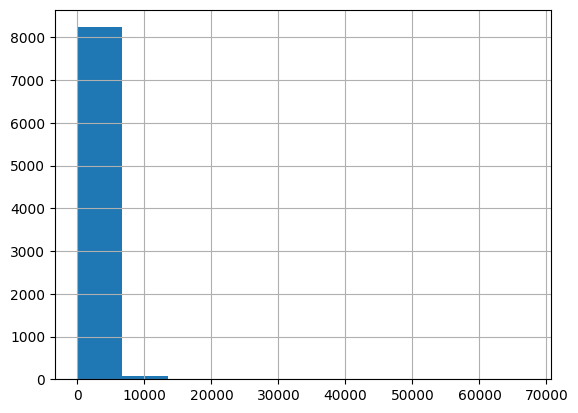

In [ ]:
df["sqft"].hist()

In [ ]:
df["sqft"].fillna(df["sqft"].median(),inplace=True)

/tmp/ipykernel_8629/469311560.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["sqft"].fillna(df["sqft"].median(),inplace=True)


<Axes: >

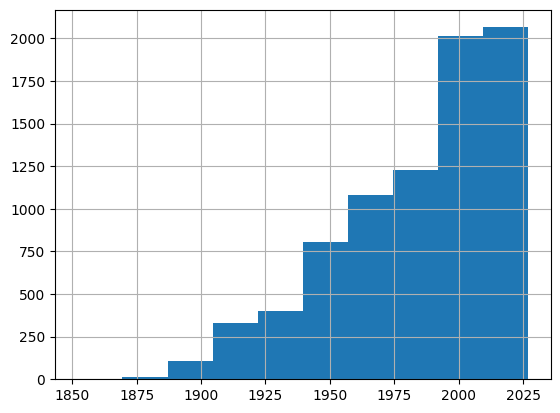

In [ ]:
df["year_built"].hist()

In [ ]:
df["year_built"].fillna(df["year_built"].median(),inplace=True)

/tmp/ipykernel_8629/1526678846.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["year_built"].fillna(df["year_built"].median(),inplace=True)


In [ ]:
df["stories"].fillna(df["stories"].mode()[0],inplace=True)

/tmp/ipykernel_8629/2650769936.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["stories"].fillna(df["stories"].mode()[0],inplace=True)


In [ ]:
df["beds"].fillna(df["beds"].mode()[0],inplace=True)

/tmp/ipykernel_8629/1303530947.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["beds"].fillna(df["beds"].mode()[0],inplace=True)


In [ ]:
df["baths"].fillna(df["baths"].mode()[0],inplace=True)

/tmp/ipykernel_8629/162700578.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["baths"].fillna(df["baths"].mode()[0],inplace=True)


In [ ]:
df["baths_full"].fillna(df["baths_full"].mode()[0],inplace=True)

/tmp/ipykernel_8629/1211944767.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["baths_full"].fillna(df["baths_full"].mode()[0],inplace=True)


In [ ]:
df["baths_full_calc"].fillna(df["baths_full_calc"].mode()[0],inplace=True)

/tmp/ipykernel_8629/2576491188.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["baths_full_calc"].fillna(df["baths_full_calc"].mode()[0],inplace=True)


In [ ]:
df["garage"].fillna(df["garage"].mode()[0],inplace=True)

/tmp/ipykernel_8629/3166203889.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["garage"].fillna(df["garage"].mode()[0],inplace=True)


In [ ]:
df.isnull().sum()

,0
type,0
listPrice,0
sqft,0
stories,0
beds,0
baths,0
baths_full,0
baths_full_calc,0
garage,0
year_built,0


In [ ]:
df.duplicated().sum()

np.int64(1247)

In [ ]:
df.shape

(10403, 10)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(9156, 10)

# visualization

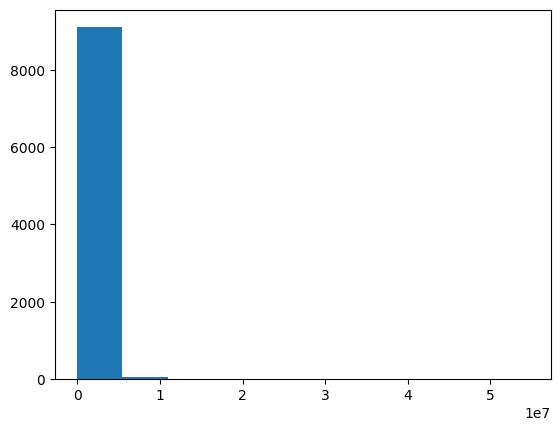

In [ ]:
plt.hist(df['listPrice'])
plt.show()

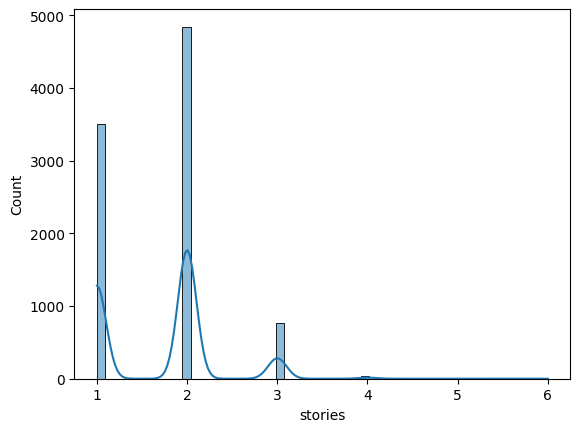

In [ ]:
sns.histplot(df["stories"],kde=True)
plt.show()

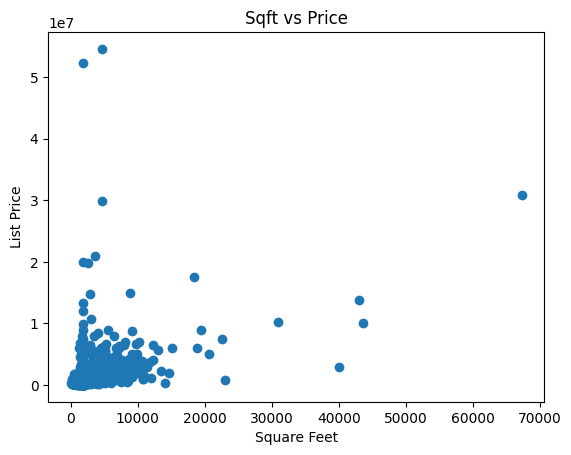

In [ ]:
plt.scatter(df["sqft"], df["listPrice"])
plt.xlabel("Square Feet")
plt.ylabel("List Price")
plt.title("Sqft vs Price")
plt.show()

# Correlation analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9156 entries, 0 to 10402
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   type             9156 non-null   object 
 1   listPrice        9156 non-null   float64
 2   sqft             9156 non-null   float64
 3   stories          9156 non-null   float64
 4   beds             9156 non-null   float64
 5   baths            9156 non-null   float64
 6   baths_full       9156 non-null   float64
 7   baths_full_calc  9156 non-null   float64
 8   garage           9156 non-null   float64
 9   year_built       9156 non-null   float64
dtypes: float64(9), object(1)
memory usage: 786.8+ KB


In [ ]:
print(df["type"].unique())

['single_family' 'condos' 'land' 'farm' 'multi_family' 'townhome'
 'unknown' 'townhomes']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['type']=le.fit_transform(df['type'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9156 entries, 0 to 10402
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   type             9156 non-null   int64  
 1   listPrice        9156 non-null   float64
 2   sqft             9156 non-null   float64
 3   stories          9156 non-null   float64
 4   beds             9156 non-null   float64
 5   baths            9156 non-null   float64
 6   baths_full       9156 non-null   float64
 7   baths_full_calc  9156 non-null   float64
 8   garage           9156 non-null   float64
 9   year_built       9156 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 786.8 KB


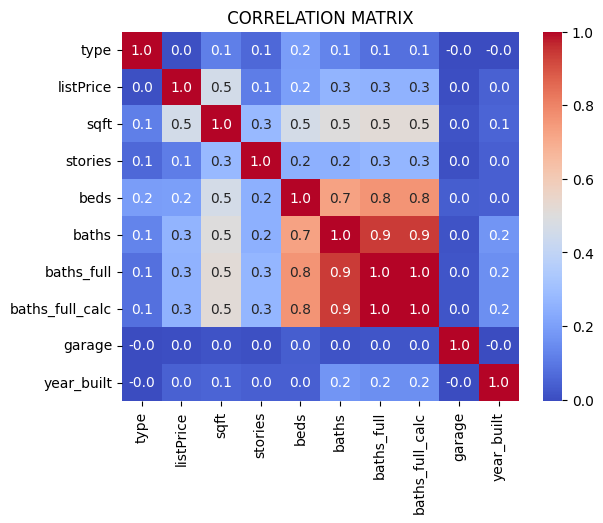

In [ ]:
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=True,fmt="0.1f",cmap="coolwarm")
plt.title(" CORRELATION MATRIX ")
plt.show()

In [ ]:
df.drop(["baths_full_calc","baths_full"],axis=1,inplace=True, errors='ignore')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9156 entries, 0 to 10402
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   type        9156 non-null   int64  
 1   listPrice   9156 non-null   float64
 2   sqft        9156 non-null   float64
 3   stories     9156 non-null   float64
 4   beds        9156 non-null   float64
 5   baths       9156 non-null   float64
 6   garage      9156 non-null   float64
 7   year_built  9156 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 643.8 KB


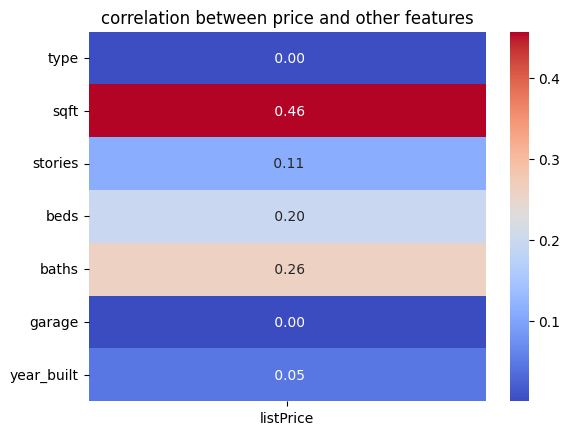

In [ ]:
status_corr=df.corr()["listPrice"]
status_corr=status_corr.drop("listPrice")
sns.heatmap(status_corr.to_frame(),annot=True,fmt=" .2f",cmap= "coolwarm",cbar=True,annot_kws={'size':10})
plt.title("correlation between price and other features")
plt.show()

In [ ]:
df.drop(["garage","type"],axis=1,inplace=True)

In [ ]:
df.shape

(9156, 6)

# Outlier Checking and removing

<Axes: >

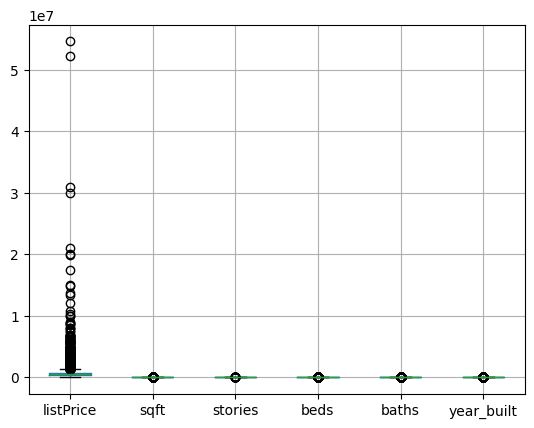

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
       continue
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR =Q3-Q1
    lower_bound = Q1 -1.5 *IQR
    upper_bound = Q3 +1.5 *IQR
    df=df[(df[col]>= lower_bound)&(df[col]<=upper_bound)]
  return df

df_cleaned= remove_outliers_iqr(df,exclude_column='price')
df=df_cleaned

In [ ]:
df.shape

(4483, 6)

# Data Scaling

In [ ]:
df.columns

Index(['listPrice', 'sqft', 'stories', 'beds', 'baths', 'year_built'], dtype='object')

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
features =['sqft', 'stories', 'beds', 'baths', 'year_built']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)

# After EDA .... our dataset is regression so use LinearRegression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=df[['sqft', 'stories', 'beds', 'baths', 'year_built']]
y=df["listPrice"]

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=LinearRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.24


In [ ]:
from sklearn.ensemble import RandomForestRegressor
x=df[['sqft', 'stories', 'beds', 'baths', 'year_built']]
y=df["listPrice"]

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=RandomForestRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.30
